In [1]:
import pandas as pd

df = pd.read_csv("../data/amazon_reviews_processed.csv")
df = df.dropna(subset=['text_clean'])
print(df.shape)
df['sentiment'].value_counts()

(65198, 7)


sentiment
positive    47137
negative    13275
neutral      4786
Name: count, dtype: int64

In [2]:
from sklearn.model_selection import train_test_split

# Stratified sample: 12,000 rows preserving class ratios
df_subset, _ = train_test_split(
    df, train_size=12000, stratify=df['sentiment'], random_state=42
)

print(df_subset.shape)
print(df_subset['sentiment'].value_counts())
print(df_subset['sentiment'].value_counts(normalize=True))

(12000, 7)
sentiment
positive    8676
negative    2443
neutral      881
Name: count, dtype: int64
sentiment
positive    0.723000
negative    0.203583
neutral     0.073417
Name: proportion, dtype: float64


In [3]:
train_df, test_df = train_test_split(
    df_subset, test_size=0.2, stratify=df_subset['sentiment'], random_state=42
)

print("Train:", train_df.shape)
print("Test:", test_df.shape)
print(train_df['sentiment'].value_counts(normalize=True))

Train: (9600, 7)
Test: (2400, 7)
sentiment
positive    0.723021
negative    0.203542
neutral     0.073438
Name: proportion, dtype: float64


In [4]:
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
id_to_label = {v: k for k, v in label_map.items()}

train_df = train_df.copy()
test_df = test_df.copy()

train_df['label'] = train_df['sentiment'].map(label_map)
test_df['label'] = test_df['sentiment'].map(label_map)

print(train_df[['text_clean', 'sentiment', 'label']].head())

                                              text_clean sentiment  label
52830  those of you who are my age will recognize tha...  positive      2
59575  this is a good magazine to keep up with the la...  positive      2
1053   like the website better because i can look up ...   neutral      1
51183  this is a gift for our daughter and she loves ...  positive      2
207         love this magazine great colors and articles  positive      2


In [5]:
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

# Quick test on one example
sample_text = train_df['text_clean'].iloc[0]
tokens = tokenizer(sample_text, truncation=True, padding='max_length', max_length=128)

print("Original text:", sample_text[:100])
print("Token IDs (first 20):", tokens['input_ids'][:20])
print("Attention mask (first 20):", tokens['attention_mask'][:20])

c:\Users\satya\Documents\sentiment-analysis-nlp\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Original text: those of you who are my age will recognize that famous line from dragnet if you have ever listened t
Token IDs (first 20): [101, 2216, 1997, 2017, 2040, 2024, 2026, 2287, 2097, 6807, 2008, 3297, 2240, 2013, 8011, 7159, 2065, 2017, 2031, 2412]
Attention mask (first 20): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [6]:
import torch

def tokenize_texts(texts, max_length=128):
    return tokenizer(
        list(texts),
        truncation=True,
        padding='max_length',
        max_length=max_length,
        return_tensors='pt'
    )

train_encodings = tokenize_texts(train_df['text_clean'])
test_encodings = tokenize_texts(test_df['text_clean'])

print("Train encodings shape:", train_encodings['input_ids'].shape)
print("Test encodings shape:", test_encodings['input_ids'].shape)

Train encodings shape: torch.Size([9600, 128])
Test encodings shape: torch.Size([2400, 128])


In [7]:
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = SentimentDataset(train_encodings, train_df['label'].tolist())
test_dataset = SentimentDataset(test_encodings, test_df['label'].tolist())

print("Train dataset size:", len(train_dataset))
print("Test dataset size:", len(test_dataset))

Train dataset size: 9600
Test dataset size: 2400


In [8]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3
)

print("Model loaded.")
print(model.config)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3321.06it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded.
DistilBertConfig {
  "activation": "gelu",
  "architectures": [
    "DistilBertForMaskedLM"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": null,
  "dim": 768,
  "dropout": 0.1,
  "dtype": "float32",
  "eos_token_id": null,
  "hidden_dim": 3072,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2"
  },
  "initializer_range": 0.02,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_2": 2
  },
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "tie_word_embeddings": true,
  "transformers_version": "5.13.0",
  "vocab_size": 30522
}



In [9]:
from transformers import TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro')
    }

training_args = TrainingArguments(
    output_dir='../models/distilbert_checkpoints',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_dir='../logs',
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

print("Trainer configured. Ready to train.")

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainer configured. Ready to train.


In [10]:
trainer.train()

c:\Users\satya\Documents\sentiment-analysis-nlp\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.404027,0.429471,0.865417,0.599947
2,0.347348,0.417040,0.870417,0.682565
3,0.173074,0.529928,0.864167,0.695004


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.62it/s]
c:\Users\satya\Documents\sentiment-analysis-nlp\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.95it/s]
c:\Users\satya\Documents\sentiment-analysis-nlp\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.26it/s]


TrainOutput(global_step=3600, training_loss=0.31672876252068416, metrics={'train_runtime': 18783.4006, 'train_samples_per_second': 1.533, 'train_steps_per_second': 0.192, 'total_flos': 953782279372800.0, 'train_loss': 0.31672876252068416, 'epoch': 3.0})

c:\Users\satya\Documents\sentiment-analysis-nlp\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

    negative       0.80      0.75      0.77       489
     neutral       0.36      0.38      0.37       176
    positive       0.93      0.95      0.94      1735

    accuracy                           0.86      2400
   macro avg       0.70      0.69      0.70      2400
weighted avg       0.86      0.86      0.86      2400



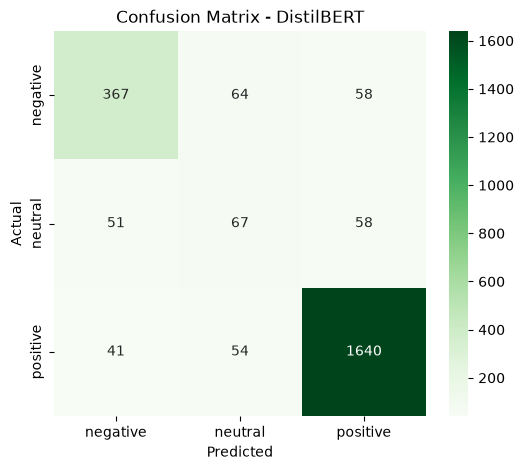

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_df['label'].tolist()

y_pred_labels = [id_to_label[p] for p in y_pred]
y_true_labels = [id_to_label[t] for t in y_true]

print(classification_report(y_true_labels, y_pred_labels))

cm = confusion_matrix(y_true_labels, y_pred_labels, labels=['negative', 'neutral', 'positive'])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['negative','neutral','positive'],
            yticklabels=['negative','neutral','positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - DistilBERT')
plt.show()

NameError: name 'tokenizer' is not defined

In [12]:
model.save_pretrained("../models/distilbert_sentiment")
tokenizer.save_pretrained("../models/distilbert_sentiment")
print("Model and tokenizer saved.")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.77it/s]

Model and tokenizer saved.


## Model Limitation Check: Very Short Reviews

Testing whether DistilBERT handles very short, telegraphic text correctly, 
since our training data's median length was 21 words (from EDA). This helps 
identify edge cases before deployment.

In [3]:
import re
import contractions
from bs4 import BeautifulSoup
import torch
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

# Load the saved fine-tuned model
tokenizer = DistilBertTokenizerFast.from_pretrained("../models/distilbert_sentiment")
model = DistilBertForSequenceClassification.from_pretrained("../models/distilbert_sentiment")
model.eval()

id_to_label = {0: 'negative', 1: 'neutral', 2: 'positive'}

def clean_text(text):
    text = str(text)
    text = BeautifulSoup(text, "html.parser").get_text(separator=' ')
    text = contractions.fix(text)
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Model, tokenizer, and functions loaded.")

c:\Users\satya\Documents\sentiment-analysis-nlp\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 4387.52it/s]

Model, tokenizer, and functions loaded.


In [4]:
test_texts = [
    "Terrible. Avoid.",
    "This is terrible, avoid it completely.",
    "Great product, works well.",
    "Bad. Do not buy.",
]

for text in test_texts:
    clean = clean_text(text)
    inputs = tokenizer(clean, truncation=True, padding='max_length', max_length=128, return_tensors='pt')
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1)[0]
    pred_id = probs.argmax().item()
    print(f"Text: {text}")
    print(f"Cleaned: {clean}")
    print(f"Probs -> negative: {probs[0]:.3f}, neutral: {probs[1]:.3f}, positive: {probs[2]:.3f}")
    print(f"Predicted: {id_to_label[pred_id]}\n")

Text: Terrible. Avoid.
Cleaned: terrible avoid
Probs -> negative: 0.001, neutral: 0.005, positive: 0.993
Predicted: positive

Text: This is terrible, avoid it completely.
Cleaned: this is terrible avoid it completely
Probs -> negative: 0.991, neutral: 0.005, positive: 0.004
Predicted: negative

Text: Great product, works well.
Cleaned: great product works well
Probs -> negative: 0.000, neutral: 0.001, positive: 0.999
Predicted: positive

Text: Bad. Do not buy.
Cleaned: bad do not buy
Probs -> negative: 0.982, neutral: 0.012, positive: 0.006
Predicted: negative

